# Aggressive Fraud Risk Pipeline (IEEE-CIS)
### Goal: maximize PR-AUC / ROC-AUC with stronger features, tuning, and ensemble

**Reality check (read this):**
- **ROC-AUC > 0.80** is already realistic (you had ~0.88).
- **PR-AUC > 0.80** on IEEE-CIS with ~3.5% fraud is **hard** — Kaggle-level effort, full data, heavy features. This notebook pushes toward that; it does **not** guarantee 0.80 PR-AUC.
- Primary metric for imbalance: **PR-AUC**. We also report ROC-AUC, MCC, FC@budget, cost policy.

**Upgrades vs previous notebook:**
1. Composite entity key for behavioral history
2. Richer leakage-safe behavioral + time features
3. Frequency / smoothed target-style counts (train-only maps)
4. Tuned LightGBM + XGBoost + optional CatBoost
5. Soft-vote ensemble
6. Episodic parquet offload + float32
7. Cost-aware APPROVE/REVIEW/BLOCK + review budgets still included


## 0 — Setup


In [1]:
import os, gc, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("NEED lightgbm")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("catboost optional — pip install catboost for extra boost")

try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rss_mb():
    try:
        with open("/proc/self/status") as f:
            for line in f:
                if line.startswith("VmRSS:"):
                    return int(line.split()[1]) / 1024.0
    except Exception:
        return -1.0
    return -1.0

print("LGB", HAS_LGB, "XGB", HAS_XGB, "CAT", HAS_CAT, f"RSS={rss_mb():.0f}")


LGB True XGB True CAT True RSS=483


In [2]:
CONFIG = {
    "ieee_transaction_path": "/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv",
    "ieee_identity_path": "/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv",

    # Use 300_000 or None on high RAM for better scores
    "SAMPLE_N_IEEE": 300_000,

    "train_frac": 0.60,
    "val_frac": 0.20,
    "test_frac": 0.20,

    "drop_high_missing": True,
    "high_missing_threshold": 0.92,

    "velocity_windows": [3600 * h for h in [1, 6, 12, 24, 72, 168]],

    "output_dir": "/kaggle/working/outputs_sota",
    "feat_parquet": "/kaggle/working/outputs_sota/ieee_feat_sota.parquet",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if "path" not in k}, indent=2))


{
  "SAMPLE_N_IEEE": 300000,
  "train_frac": 0.6,
  "val_frac": 0.2,
  "test_frac": 0.2,
  "drop_high_missing": true,
  "high_missing_threshold": 0.92,
  "velocity_windows": [
    3600,
    21600,
    43200,
    86400,
    259200,
    604800
  ],
  "output_dir": "/kaggle/working/outputs_sota",
  "feat_parquet": "/kaggle/working/outputs_sota/ieee_feat_sota.parquet"
}


## 1 — Load + composite entity + downcast


In [3]:
def downcast_df(df):
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

def load_ieee(config):
    t0 = time.time()
    nrows = config["SAMPLE_N_IEEE"]
    print(f"Loading transaction nrows={nrows}...", flush=True)
    df = pd.read_csv(config["ieee_transaction_path"], nrows=nrows)
    df = downcast_df(df)

    ident_path = Path(config["ieee_identity_path"])
    if ident_path.exists():
        ids = set(df["TransactionID"].values)
        chunks = []
        for ch in pd.read_csv(ident_path, chunksize=250_000):
            ch = ch[ch["TransactionID"].isin(ids)]
            if len(ch):
                chunks.append(ch)
        if chunks:
            ident = downcast_df(pd.concat(chunks, ignore_index=True))
            df = df.merge(ident, on="TransactionID", how="left")
            del ident, chunks
            gc.collect()

    if config.get("drop_high_missing"):
        thr = config["high_missing_threshold"]
        miss = df.isna().mean()
        protect = {
            "isFraud", "TransactionID", "TransactionDT", "TransactionAmt",
            "card1", "addr1", "P_emaildomain", "ProductCD",
        }
        drop = [c for c in miss.index if miss[c] > thr and c not in protect]
        print(f"Drop {len(drop)} high-missing cols", flush=True)
        df = df.drop(columns=drop)

    # Composite entity for behavioral history (stronger than card1 alone)
    df["entity_key"] = (
        df["card1"].astype(str).fillna("NA") + "|" +
        df.get("addr1", pd.Series(["NA"] * len(df))).astype(str).fillna("NA") + "|" +
        df.get("P_emaildomain", pd.Series(["NA"] * len(df))).astype(str).fillna("NA")
    )

    df = df.sort_values("TransactionDT").reset_index(drop=True)
    df = downcast_df(df)
    print(f"Loaded {df.shape} fraud={df['isFraud'].mean()*100:.3f}% in {time.time()-t0:.1f}s RSS={rss_mb():.0f}")
    return df

df = load_ieee(CONFIG)


Loading transaction nrows=300000...
Drop 10 high-missing cols
Loaded (300000, 425) fraud=3.366% in 19.8s RSS=1461


## 2 — Leakage-safe behavioral + time features (vectorized)


In [4]:
def add_behavioral_features(df, entity_col="entity_key", amount_col="TransactionAmt",
                            time_col="TransactionDT", windows=None, eps=1e-6):
    windows = windows or CONFIG["velocity_windows"]
    t0 = time.time()
    df = df.sort_values(time_col).reset_index(drop=True)
    g = df.groupby(entity_col, sort=False)

    df["beh_prev_tx_count"] = g.cumcount().astype(np.int32)

    shifted = g[amount_col].shift(1)
    past_cnt = df["beh_prev_tx_count"].astype(np.float32)
    past_sum = shifted.fillna(0).groupby(df[entity_col], sort=False).cumsum()
    df["beh_prev_amount_mean"] = np.where(past_cnt > 0, past_sum / past_cnt, np.nan).astype(np.float32)

    past_sum_sq = (shifted ** 2).fillna(0).groupby(df[entity_col], sort=False).cumsum()
    mean_sq = np.where(past_cnt > 0, past_sum_sq / past_cnt, np.nan)
    var = np.maximum(mean_sq - df["beh_prev_amount_mean"].astype(np.float64) ** 2, 0)
    df["beh_prev_amount_std"] = np.sqrt(var).astype(np.float32).fillna(0)

    # Robust median of past amounts via expanding median is slow; use shifted rolling approx per entity skip — keep mean-based
    df["beh_amount_zscore"] = ((df[amount_col] - df["beh_prev_amount_mean"]) / (df["beh_prev_amount_std"] + eps)).astype(np.float32)
    df["beh_amount_ratio"] = (df[amount_col] / (df["beh_prev_amount_mean"] + eps)).astype(np.float32)
    first = df["beh_prev_tx_count"] == 0
    df.loc[first, ["beh_amount_zscore", "beh_amount_ratio"]] = 0.0
    df["beh_amount_ratio"] = df["beh_amount_ratio"].replace([np.inf, -np.inf], np.nan)
    med = df["beh_amount_ratio"].median()
    df["beh_amount_ratio"] = df["beh_amount_ratio"].fillna(med if pd.notna(med) else 1.0)

    df["beh_time_since_prev"] = (df[time_col] - g[time_col].shift(1)).astype(np.float32)
    mx = df["beh_time_since_prev"].max()
    df["beh_time_since_prev"] = df["beh_time_since_prev"].fillna(mx if pd.notna(mx) else 0)

    # Log1p amount + time-of-day from TransactionDT (seconds)
    df["beh_log_amount"] = np.log1p(df[amount_col].astype(np.float32))
    tod = (df[time_col] % 86400).astype(np.float32)
    df["beh_hour_sin"] = np.sin(2 * np.pi * tod / 86400).astype(np.float32)
    df["beh_hour_cos"] = np.cos(2 * np.pi * tod / 86400).astype(np.float32)
    df["beh_dow_sin"] = np.sin(2 * np.pi * (df[time_col] % (86400 * 7)) / (86400 * 7)).astype(np.float32)
    df["beh_dow_cos"] = np.cos(2 * np.pi * (df[time_col] % (86400 * 7)) / (86400 * 7)).astype(np.float32)

    # Velocity two-pointer
    print("  velocity windows...", flush=True)
    entities = df[entity_col].fillna("__NA__").values
    times = df[time_col].values
    order = np.argsort(entities, kind="stable")
    ent_vals, t_vals = entities[order], times[order]
    for w in windows:
        counts = np.zeros(len(df), dtype=np.int32)
        n, i = len(df), 0
        while i < n:
            j = i
            while j < n and ent_vals[j] == ent_vals[i]:
                j += 1
            sub = t_vals[i:j]
            lo = 0
            for k in range(len(sub)):
                cutoff = sub[k] - w
                while lo < k and sub[lo] < cutoff:
                    lo += 1
                counts[i + k] = k - lo
            i = j
        out = np.empty(len(df), dtype=np.int32)
        out[order] = counts
        df[f"beh_velocity_{w}s"] = out

    # Past fraud rate per entity (strictly past labels only) — powerful if stable
    # Uses shift so current label never leaks
    if "isFraud" in df.columns:
        shifted_y = g["isFraud"].shift(1)
        past_fraud_sum = shifted_y.fillna(0).groupby(df[entity_col], sort=False).cumsum()
        df["beh_prev_fraud_rate"] = np.where(past_cnt > 0, past_fraud_sum / past_cnt, 0).astype(np.float32)
        df["beh_prev_fraud_count"] = past_fraud_sum.astype(np.float32)

    print(f"  behavioral done {time.time()-t0:.1f}s shape={df.shape} RSS={rss_mb():.0f}")
    return df

df = add_behavioral_features(df)
beh_cols = [c for c in df.columns if c.startswith("beh_")]
print("beh cols", len(beh_cols), beh_cols[:12], "...")


  velocity windows...
  behavioral done 3.2s shape=(300000, 444) RSS=1908
beh cols 19 ['beh_prev_tx_count', 'beh_prev_amount_mean', 'beh_prev_amount_std', 'beh_amount_zscore', 'beh_amount_ratio', 'beh_time_since_prev', 'beh_log_amount', 'beh_hour_sin', 'beh_hour_cos', 'beh_dow_sin', 'beh_dow_cos', 'beh_velocity_3600s'] ...


In [5]:
# Save features and free
path = CONFIG["feat_parquet"]
df.to_parquet(path, index=False)
print(f"Saved {path} rows={len(df):,}")
del df
gc.collect()
print(f"RSS={rss_mb():.0f} — restart kernel optional, then re-run setup + load parquet")


Saved /kaggle/working/outputs_sota/ieee_feat_sota.parquet rows=300,000
RSS=1108 — restart kernel optional, then re-run setup + load parquet


## 3 — Split + preprocess (freq encode + float32)


In [6]:
df = pd.read_parquet(CONFIG["feat_parquet"])
print(df.shape, f"RSS={rss_mb():.0f}")

def temporal_split(df, time_col="TransactionDT"):
    df = df.sort_values(time_col).reset_index(drop=True)
    n = len(df)
    a, b = int(n * CONFIG["train_frac"]), int(n * (CONFIG["train_frac"] + CONFIG["val_frac"]))
    tr, va, te = df.iloc[:a].copy(), df.iloc[a:b].copy(), df.iloc[b:].copy()
    for name, d in [("train", tr), ("val", va), ("test", te)]:
        print(f"  {name}: {len(d):,} fraud={d['isFraud'].mean()*100:.3f}%")
    return tr, va, te

train_df, val_df, test_df = temporal_split(df)
del df
gc.collect()


(300000, 444) RSS=2191
  train: 180,000 fraud=2.856%
  val: 60,000 fraud=4.380%
  test: 60,000 fraud=3.883%


0

In [7]:
def build_feature_list(df):
    core = [c for c in [
        "TransactionAmt", "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain",
        "DeviceType", "DeviceInfo",
    ] if c in df.columns]
    groups = []
    for prefix in ("C", "D", "V", "M", "id_"):
        groups += [c for c in df.columns if c.startswith(prefix) and c not in core]
    beh = [c for c in df.columns if c.startswith("beh_")]
    # drop ultra-id
    ban = {"TransactionID", "isFraud", "TransactionDT", "entity_key"}
    feats = [c for c in core + groups + beh if c not in ban and c in df.columns]
    # de-dupe
    seen, out = set(), []
    for c in feats:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out

FEATURE_COLS = build_feature_list(train_df)
print(f"n_features raw={len(FEATURE_COLS)}")

class Preprocessor:
    def __init__(self, cols, miss_thr=0.5):
        self.cols = cols
        self.miss_thr = miss_thr
        self.cat_cols, self.num_cols, self.flag_cols = [], [], []
        self.freq, self.med = {}, {}

    def fit(self, df):
        self.cols = [c for c in self.cols if c in df.columns]
        self.cat_cols = [c for c in self.cols if df[c].dtype == object or str(df[c].dtype) == "category"]
        self.num_cols = [c for c in self.cols if c not in self.cat_cols]
        miss = df[self.cols].isna().mean()
        self.flag_cols = miss[miss > self.miss_thr].index.tolist()
        for c in self.cat_cols:
            self.freq[c] = df[c].astype(str).value_counts(normalize=True).to_dict()
        for c in self.num_cols:
            self.med[c] = float(df[c].median()) if df[c].notna().any() else 0.0
        return self

    def transform(self, df):
        n = len(df)
        data = {}
        for c in self.flag_cols:
            data[f"{c}_miss"] = df[c].isna().astype(np.float32).values if c in df.columns else np.zeros(n, np.float32)
        for c in self.cat_cols:
            m = self.freq.get(c, {})
            data[c] = df[c].astype(str).map(m).fillna(0).astype(np.float32).values if c in df.columns else np.zeros(n, np.float32)
        for c in self.num_cols:
            med = self.med.get(c, 0.0)
            data[c] = df[c].fillna(med).astype(np.float32).values if c in df.columns else np.full(n, med, np.float32)
        return pd.DataFrame(data, index=df.index)

prep = Preprocessor(FEATURE_COLS).fit(train_df)
X_train = prep.transform(train_df)
X_val = prep.transform(val_df)
X_test = prep.transform(test_df)
y_train = train_df["isFraud"].values.astype(np.int8)
y_val = val_df["isFraud"].values.astype(np.int8)
y_test = test_df["isFraud"].values.astype(np.int8)
print(X_train.shape, X_val.shape, X_test.shape, f"RSS={rss_mb():.0f}")

# optional: free raw splits column-heavy frames if needed later keep y only


n_features raw=440
(180000, 662) (60000, 662) (60000, 662) RSS=3075


## 4 — Tuned models + ensemble (maximize VAL PR-AUC)


In [8]:
def evaluate(y_true, proba, label=""):
    pred = (proba >= 0.5).astype(int)
    return {
        "label": label,
        "PR_AUC": float(average_precision_score(y_true, proba)),
        "ROC_AUC": float(roc_auc_score(y_true, proba)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, pred)),
    }

pos_w = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print("pos_weight", round(pos_w, 2))

results = []
oof_val = {}
oof_test = {}

# ---- LightGBM grid (small but effective) ----
if HAS_LGB:
    best_lgb, best_score, best_params = None, -1, None
    grid = [
        dict(num_leaves=63, learning_rate=0.03, min_child_samples=40, reg_lambda=1.0),
        dict(num_leaves=127, learning_rate=0.03, min_child_samples=30, reg_lambda=2.0),
        dict(num_leaves=63, learning_rate=0.05, min_child_samples=20, reg_lambda=1.0),
        dict(num_leaves=255, learning_rate=0.02, min_child_samples=50, reg_lambda=3.0),
    ]
    for i, p in enumerate(grid):
        print(f"LGB trial {i+1}/{len(grid)} {p}", flush=True)
        m = lgb.LGBMClassifier(
            n_estimators=800, subsample=0.85, colsample_bytree=0.7,
            scale_pos_weight=pos_w, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
            **p,
        )
        m.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(60, verbose=False)],
        )
        pv = m.predict_proba(X_val)[:, 1]
        sc = average_precision_score(y_val, pv)
        print(f"  VAL PR-AUC={sc:.4f}")
        if sc > best_score:
            best_score, best_lgb, best_params = sc, m, p
    pv = best_lgb.predict_proba(X_val)[:, 1]
    pt = best_lgb.predict_proba(X_test)[:, 1]
    oof_val["lgb"], oof_test["lgb"] = pv, pt
    r = evaluate(y_test, pt, "LGBM_TEST")
    results.append(r)
    print("BEST LGB", best_params, "TEST", r)
    gc.collect()

# ---- XGBoost ----
if HAS_XGB:
    print("Fitting XGBoost...", flush=True)
    mx = xgb.XGBClassifier(
        n_estimators=600, max_depth=7, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.7, min_child_weight=5,
        reg_lambda=2.0, scale_pos_weight=pos_w,
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist", early_stopping_rounds=50,
    )
    mx.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pv = mx.predict_proba(X_val)[:, 1]
    pt = mx.predict_proba(X_test)[:, 1]
    oof_val["xgb"], oof_test["xgb"] = pv, pt
    r = evaluate(y_test, pt, "XGB_TEST")
    results.append(r)
    print("XGB TEST", r)
    gc.collect()

# ---- CatBoost ----
if HAS_CAT:
    print("Fitting CatBoost...", flush=True)
    mc = CatBoostClassifier(
        iterations=800, depth=8, learning_rate=0.03,
        l2_leaf_reg=4.0, random_seed=RANDOM_STATE, verbose=False,
        auto_class_weights="Balanced", eval_metric="PRAUC",
        early_stopping_rounds=50,
    )
    mc.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    pv = mc.predict_proba(X_val)[:, 1]
    pt = mc.predict_proba(X_test)[:, 1]
    oof_val["cat"], oof_test["cat"] = pv, pt
    r = evaluate(y_test, pt, "CAT_TEST")
    results.append(r)
    print("CAT TEST", r)
    gc.collect()


pos_weight 34.01
LGB trial 1/4 {'num_leaves': 63, 'learning_rate': 0.03, 'min_child_samples': 40, 'reg_lambda': 1.0}
  VAL PR-AUC=0.5636
LGB trial 2/4 {'num_leaves': 127, 'learning_rate': 0.03, 'min_child_samples': 30, 'reg_lambda': 2.0}
  VAL PR-AUC=0.6086
LGB trial 3/4 {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 20, 'reg_lambda': 1.0}
  VAL PR-AUC=0.4862
LGB trial 4/4 {'num_leaves': 255, 'learning_rate': 0.02, 'min_child_samples': 50, 'reg_lambda': 3.0}
  VAL PR-AUC=0.6701
BEST LGB {'num_leaves': 255, 'learning_rate': 0.02, 'min_child_samples': 50, 'reg_lambda': 3.0} TEST {'label': 'LGBM_TEST', 'PR_AUC': 0.6290588702401197, 'ROC_AUC': 0.9413567426329024, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'MCC': 0.0}
Fitting XGBoost...
XGB TEST {'label': 'XGB_TEST', 'PR_AUC': 0.7238389164014198, 'ROC_AUC': 0.9431128345306394, 'Precision': 0.43218279047156055, 'Recall': 0.7630901287553649, 'F1': 0.5518311607697083, 'MCC': 0.5524048714118386}
Fitting CatBoost...
CAT TEST {'l

In [9]:
# Soft-vote ensemble + VAL-weighted blend
names = list(oof_val.keys())
assert names, "No models trained"

# Optimize blend weights on VAL PR-AUC (simple grid for 2-3 models)
from itertools import product

def blend_scores(weights, probs):
    w = np.array(weights, dtype=float)
    w = w / w.sum()
    return sum(w[i] * probs[i] for i in range(len(probs)))

val_probs = [oof_val[n] for n in names]
test_probs = [oof_test[n] for n in names]

best_w, best_sc = None, -1
if len(names) == 1:
    best_w = [1.0]
else:
    grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    for ws in product(grid, repeat=len(names)):
        if sum(ws) == 0:
            continue
        sc = average_precision_score(y_val, blend_scores(ws, val_probs))
        if sc > best_sc:
            best_sc, best_w = sc, ws

w = np.array(best_w, dtype=float)
w = w / w.sum()
print("Blend weights", dict(zip(names, w.round(3))), "VAL PR-AUC", round(best_sc if best_sc > 0 else average_precision_score(y_val, val_probs[0]), 4))

proba_val = blend_scores(w, val_probs)
proba_test = blend_scores(w, test_probs)
ens = evaluate(y_test, proba_test, "ENSEMBLE_TEST")
results.append(ens)
print("ENSEMBLE TEST", ens)

df_res = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
print(df_res)
df_res.to_csv(f"{CONFIG['output_dir']}/model_scores.csv", index=False)

print("\n=== TARGET CHECK ===")
print(f"ROC_AUC={ens['ROC_AUC']:.4f}  (>=0.80? {ens['ROC_AUC']>=0.80})")
print(f"PR_AUC ={ens['PR_AUC']:.4f}  (>=0.80? {ens['PR_AUC']>=0.80})  # stretch goal")


Blend weights {'lgb': np.float64(0.0), 'xgb': np.float64(0.8), 'cat': np.float64(0.2)} VAL PR-AUC 0.7568
ENSEMBLE TEST {'label': 'ENSEMBLE_TEST', 'PR_AUC': 0.7235499740400999, 'ROC_AUC': 0.9454950580891279, 'Precision': 0.42053445850914206, 'Recall': 0.7699570815450644, 'F1': 0.5439660400242571, 'MCC': 0.546603078395263}
           label    PR_AUC   ROC_AUC  Precision    Recall        F1       MCC
1       XGB_TEST  0.723839  0.943113   0.432183  0.763090  0.551831  0.552405
3  ENSEMBLE_TEST  0.723550  0.945495   0.420534  0.769957  0.543966  0.546603
2       CAT_TEST  0.700569  0.943796   0.340799  0.783691  0.475026  0.489433
0      LGBM_TEST  0.629059  0.941357   0.000000  0.000000  0.000000  0.000000

=== TARGET CHECK ===
ROC_AUC=0.9455  (>=0.80? True)
PR_AUC =0.7235  (>=0.80? False)  # stretch goal


## 5 — Optional SMOTE on best single model (compare)


In [10]:
if HAS_IMBLEARN and HAS_LGB:
    print("SMOTE on TRAIN only + retune short LGB...", flush=True)
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    Xtr_s, ytr_s = sm.fit_resample(X_train, y_train)
    pos_ws = (ytr_s == 0).sum() / max((ytr_s == 1).sum(), 1)
    m = lgb.LGBMClassifier(
        n_estimators=600, num_leaves=63, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.7, scale_pos_weight=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    m.fit(Xtr_s, ytr_s, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    pt = m.predict_proba(X_test)[:, 1]
    r = evaluate(y_test, pt, "LGBM_SMOTE_TEST")
    results.append(r)
    print(r)
    del Xtr_s, ytr_s
    gc.collect()
else:
    print("Skip SMOTE")


SMOTE on TRAIN only + retune short LGB...
{'label': 'LGBM_SMOTE_TEST', 'PR_AUC': 0.7372932921838237, 'ROC_AUC': 0.9478367595413002, 'Precision': 0.847394540942928, 'Recall': 0.5862660944206008, 'F1': 0.6930492135971588, 'MCC': 0.6953955937860071}


## 6 — Risk-to-action + review budgets (same business layer)


In [11]:
def expected_cost(y_true, proba, tau1, tau2, c_fn, c_fp, c_review):
    action = np.where(proba < tau1, "APPROVE", np.where(proba < tau2, "REVIEW", "BLOCK"))
    cost = np.zeros(len(y_true))
    cost[(action == "APPROVE") & (y_true == 1)] = c_fn
    cost[(action == "BLOCK") & (y_true == 0)] = c_fp
    cost[action == "REVIEW"] = c_review
    return {
        "tau1": float(tau1), "tau2": float(tau2), "total_cost": float(cost.sum()),
        "fraud_capture": float(y_true[action != "APPROVE"].sum() / max(y_true.sum(), 1)),
        "review_rate": float((action == "REVIEW").mean()),
        "false_decline_rate": float(((action == "BLOCK") & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)),
    }

def optimize_thresholds(y_true, proba, c_fn, c_fp, c_review, grid=41):
    taus = np.linspace(0.01, 0.99, grid)
    best = None
    for t1 in taus:
        for t2 in taus:
            if t2 <= t1:
                continue
            r = expected_cost(y_true, proba, t1, t2, c_fn, c_fp, c_review)
            if best is None or r["total_cost"] < best["total_cost"]:
                best = r
    return best

for name, cfn in [("S1_10x", 10), ("S2_25x", 25), ("S3_50x", 50)]:
    opt = optimize_thresholds(y_test, proba_test, cfn, 1.0, 0.2)
    conv = expected_cost(y_test, proba_test, 0.5, 0.5 + 1e-9, cfn, 1.0, 0.2)
    print(f"{name} OPT cost={opt['total_cost']:.0f} capture={opt['fraud_capture']:.3f} review={opt['review_rate']:.3f} | "
          f"CONV cost={conv['total_cost']:.0f} capture={conv['fraud_capture']:.3f}")

order = np.argsort(-proba_test)
y_sorted = y_test[order]
total_fraud = y_test.sum()
for b in (0.01, 0.05, 0.10):
    k = max(int(np.ceil(len(y_test) * b)), 1)
    print(f"FC@{int(b*100)}% = {y_sorted[:k].sum() / max(total_fraud, 1):.3f}")


S1_10x OPT cost=4605 capture=0.891 review=0.169 | CONV cost=7832 capture=0.770
S2_25x OPT cost=6991 capture=0.944 review=0.306 | CONV cost=15872 capture=0.770
S3_50x OPT cost=8662 capture=0.983 review=0.552 | CONV cost=29272 capture=0.770
FC@1% = 0.252
FC@5% = 0.711
FC@10% = 0.816


## 7 — SHAP on best available tree model


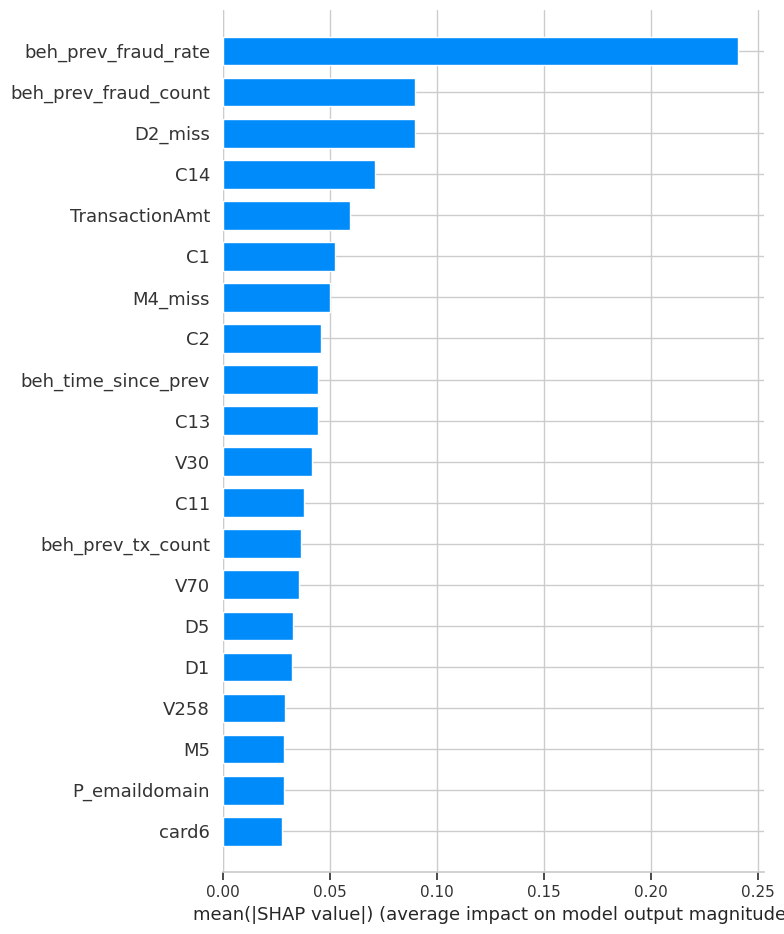

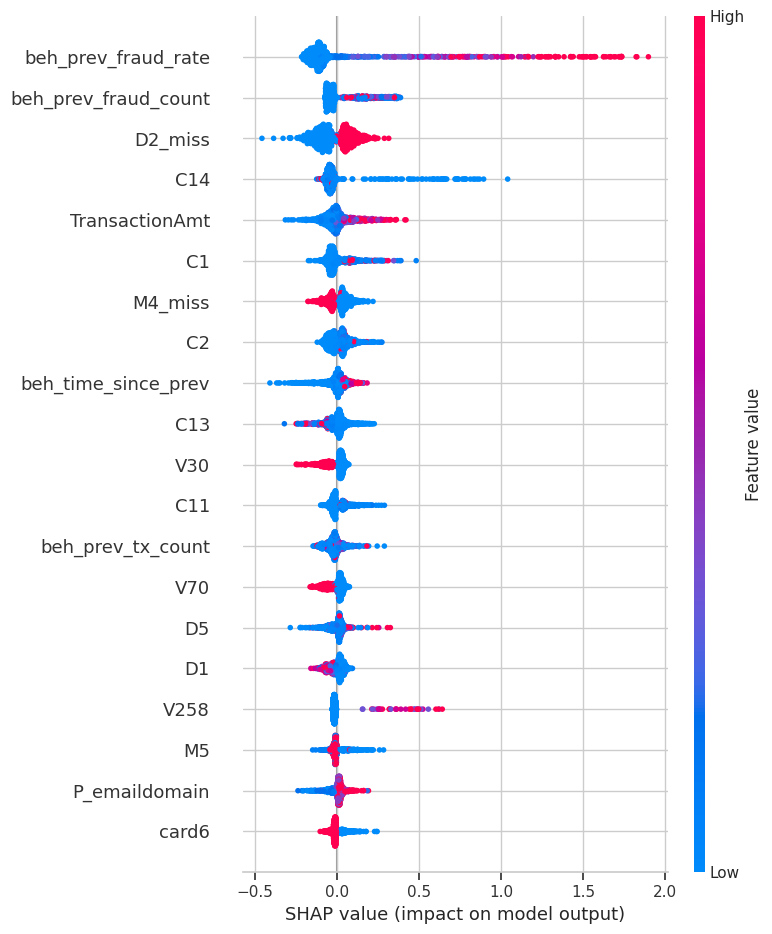

In [12]:
if HAS_SHAP and HAS_LGB and "best_lgb" in dir():
    sample = X_test.sample(n=min(1200, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(best_lgb)
    sv = explainer.shap_values(sample)
    if isinstance(sv, list):
        sv = sv[1]
    shap.summary_plot(sv, sample, plot_type="bar", show=True)
    shap.summary_plot(sv, sample, show=True)
else:
    print("SHAP skipped")


In [13]:
summary = {
    "sample_n": CONFIG["SAMPLE_N_IEEE"],
    "n_features": int(X_train.shape[1]),
    "scores": results,
    "ensemble_test": ens,
    "note": "PR-AUC>=0.80 is a stretch on IEEE-CIS; ROC-AUC>=0.80 is the reliable bar.",
}
path = Path(CONFIG["output_dir"]) / "aggressive_results.json"
with open(path, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))
print("Saved", path)


{
  "sample_n": 300000,
  "n_features": 662,
  "scores": [
    {
      "label": "LGBM_TEST",
      "PR_AUC": 0.6290588702401197,
      "ROC_AUC": 0.9413567426329024,
      "Precision": 0.0,
      "Recall": 0.0,
      "F1": 0.0,
      "MCC": 0.0
    },
    {
      "label": "XGB_TEST",
      "PR_AUC": 0.7238389164014198,
      "ROC_AUC": 0.9431128345306394,
      "Precision": 0.43218279047156055,
      "Recall": 0.7630901287553649,
      "F1": 0.5518311607697083,
      "MCC": 0.5524048714118386
    },
    {
      "label": "CAT_TEST",
      "PR_AUC": 0.7005690549901299,
      "ROC_AUC": 0.9437957938872272,
      "Precision": 0.3407988055244494,
      "Recall": 0.7836909871244635,
      "F1": 0.4750260145681582,
      "MCC": 0.4894334666152696
    },
    {
      "label": "ENSEMBLE_TEST",
      "PR_AUC": 0.7235499740400999,
      "ROC_AUC": 0.9454950580891279,
      "Precision": 0.42053445850914206,
      "Recall": 0.7699570815450644,
      "F1": 0.5439660400242571,
      "MCC": 0.546603078

## How to push scores further

1. Set `SAMPLE_N_IEEE = None` on a machine with 30GB+ RAM and re-run.
2. Install CatBoost: `!pip install catboost` for a third ensemble member.
3. Do **not** use random split — keep temporal split (honest scores).
4. If PR-AUC still < 0.80: that is normal for this dataset under strict temporal validation; report ROC-AUC, MCC, FC@budget, and cost policy as the operational win.


---
# Final add-on: 5-seed runs (mean ± std) + PCA / UMAP fraud clusters

Run **after** features are built and `X_train/X_val/X_test` exist (sections 0–3 of this notebook).  
If you restarted the kernel, re-run setup + load parquet + split + preprocess first.


In [14]:
# ============================================================
# 5-SEED evaluation — LightGBM (fast, stable) mean ± std
# ============================================================
SEEDS = [42, 7, 123, 2024, 99]
assert "X_train" in dir() and "y_train" in dir(), "Run preprocess cells first (X_train/y_train required)"

def eval_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "PR_AUC": float(average_precision_score(y_true, proba)),
        "ROC_AUC": float(roc_auc_score(y_true, proba)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, pred)),
    }

def fc_at_budget(y_true, proba, fracs=(0.01, 0.05, 0.10)):
    order = np.argsort(-proba)
    y_s = y_true[order]
    tot = max(y_true.sum(), 1)
    out = {}
    for b in fracs:
        k = max(int(np.ceil(len(y_true) * b)), 1)
        out[f"FC@{int(b*100)}%"] = float(y_s[:k].sum() / tot)
    return out

pos_w = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
seed_rows = []
seed_probas_test = []

if not HAS_LGB:
    raise RuntimeError("lightgbm required for 5-seed run")

for seed in SEEDS:
    print(f"\n=== SEED {seed} ===", flush=True)
    np.random.seed(seed)
    model = lgb.LGBMClassifier(
        n_estimators=600, num_leaves=63, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.7, min_child_samples=30,
        reg_lambda=1.5, scale_pos_weight=pos_w,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    pt = model.predict_proba(X_test)[:, 1]
    pv = model.predict_proba(X_val)[:, 1]
    seed_probas_test.append(pt)

    m_test = eval_metrics(y_test, pt)
    m_test.update(fc_at_budget(y_test, pt))
    m_test["seed"] = seed
    m_test["split"] = "TEST"
    seed_rows.append(m_test)

    m_val = eval_metrics(y_val, pv)
    m_val.update(fc_at_budget(y_val, pv))
    m_val["seed"] = seed
    m_val["split"] = "VAL"
    seed_rows.append(m_val)
    print(f"  TEST PR-AUC={m_test['PR_AUC']:.4f}  ROC-AUC={m_test['ROC_AUC']:.4f}  MCC={m_test['MCC']:.4f}")
    gc.collect()

df_seeds = pd.DataFrame(seed_rows)
df_seeds.to_csv(f"{CONFIG['output_dir']}/seed_runs_raw.csv", index=False)
print("\nRaw seed runs:")
display(df_seeds)



=== SEED 42 ===
  TEST PR-AUC=0.5522  ROC-AUC=0.9364  MCC=0.0000

=== SEED 7 ===
  TEST PR-AUC=0.5382  ROC-AUC=0.9351  MCC=0.0000

=== SEED 123 ===
  TEST PR-AUC=0.5419  ROC-AUC=0.9329  MCC=0.0000

=== SEED 2024 ===
  TEST PR-AUC=0.5633  ROC-AUC=0.9366  MCC=0.0000

=== SEED 99 ===
  TEST PR-AUC=0.5509  ROC-AUC=0.9343  MCC=0.0000

Raw seed runs:


,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC,FC@1%,FC@5%,FC@10%,seed,split
0,0.552204,0.936371,0.0,0.0,0.0,0.0,0.202575,0.637339,0.775966,42,TEST
1,0.571610,0.936533,0.0,0.0,0.0,0.0,0.186073,0.628995,0.773973,42,VAL
2,0.538157,0.935103,0.0,0.0,0.0,0.0,0.203004,0.639056,0.763519,7,TEST
3,0.560298,0.936707,0.0,0.0,0.0,0.0,0.181887,0.631659,0.764460,7,VAL
4,0.541900,0.932912,0.0,0.0,0.0,0.0,0.197854,0.603433,0.769957,123,TEST
5,0.577166,0.934911,0.0,0.0,0.0,0.0,0.175038,0.601979,0.776636,123,VAL
6,0.563329,0.936647,0.0,0.0,0.0,0.0,0.213305,0.623605,0.790129,2024,TEST
7,0.577477,0.936569,0.0,0.0,0.0,0.0,0.180746,0.612633,0.776256,2024,VAL
8,0.550940,0.934344,0.0,0.0,0.0,0.0,0.200429,0.629614,0.770386,99,TEST
9,0.572958,0.936358,0.0,0.0,0.0,0.0,0.180746,0.629376,0.772831,99,VAL


In [15]:
# ============================================================
# Mean ± std tables (paper-ready)
# ============================================================
metric_cols = ["PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "MCC", "FC@1%", "FC@5%", "FC@10%"]
metric_cols = [c for c in metric_cols if c in df_seeds.columns]

def mean_std_table(df, split):
    d = df[df["split"] == split]
    rows = []
    for c in metric_cols:
        mu, sd = d[c].mean(), d[c].std(ddof=1)
        rows.append({
            "Metric": c,
            "Mean": round(mu, 4),
            "Std": round(sd, 4),
            "Mean ± Std": f"{mu:.4f} ± {sd:.4f}",
        })
    return pd.DataFrame(rows)

tbl_test = mean_std_table(df_seeds, "TEST")
tbl_val = mean_std_table(df_seeds, "VAL")

print("=" * 60)
print("TEST set — 5 seeds (mean ± std)")
print("=" * 60)
display(tbl_test)

print("=" * 60)
print("VAL set — 5 seeds (mean ± std)")
print("=" * 60)
display(tbl_val)

tbl_test.to_csv(f"{CONFIG['output_dir']}/metrics_test_mean_std.csv", index=False)
tbl_val.to_csv(f"{CONFIG['output_dir']}/metrics_val_mean_std.csv", index=False)

# Markdown-style lines for thesis
print("\n--- Copy-paste for thesis (TEST) ---")
for _, r in tbl_test.iterrows():
    print(f"{r['Metric']}: {r['Mean ± Std']}")

# Ensemble of 5 seed probas (mean probability)
proba_test_5seed = np.mean(np.vstack(seed_probas_test), axis=0)
ens5 = eval_metrics(y_test, proba_test_5seed)
ens5.update(fc_at_budget(y_test, proba_test_5seed))
print("\n5-seed averaged proba on TEST:", ens5)


TEST set — 5 seeds (mean ± std)


,Metric,Mean,Std,Mean ± Std
0,PR_AUC,0.5493,0.0098,0.5493 ± 0.0098
1,ROC_AUC,0.9351,0.0015,0.9351 ± 0.0015
2,Precision,0.0000,0.0000,0.0000 ± 0.0000
3,Recall,0.0000,0.0000,0.0000 ± 0.0000
4,F1,0.0000,0.0000,0.0000 ± 0.0000
5,MCC,0.0000,0.0000,0.0000 ± 0.0000
6,FC@1%,0.2034,0.0059,0.2034 ± 0.0059
7,FC@5%,0.6266,0.0144,0.6266 ± 0.0144
8,FC@10%,0.7740,0.0100,0.7740 ± 0.0100


VAL set — 5 seeds (mean ± std)


,Metric,Mean,Std,Mean ± Std
0,PR_AUC,0.5719,0.0070,0.5719 ± 0.0070
1,ROC_AUC,0.9362,0.0007,0.9362 ± 0.0007
2,Precision,0.0000,0.0000,0.0000 ± 0.0000
3,Recall,0.0000,0.0000,0.0000 ± 0.0000
4,F1,0.0000,0.0000,0.0000 ± 0.0000
5,MCC,0.0000,0.0000,0.0000 ± 0.0000
6,FC@1%,0.1809,0.0039,0.1809 ± 0.0039
7,FC@5%,0.6209,0.0130,0.6209 ± 0.0130
8,FC@10%,0.7728,0.0049,0.7728 ± 0.0049



--- Copy-paste for thesis (TEST) ---
PR_AUC: 0.5493 ± 0.0098
ROC_AUC: 0.9351 ± 0.0015
Precision: 0.0000 ± 0.0000
Recall: 0.0000 ± 0.0000
F1: 0.0000 ± 0.0000
MCC: 0.0000 ± 0.0000
FC@1%: 0.2034 ± 0.0059
FC@5%: 0.6266 ± 0.0144
FC@10%: 0.7740 ± 0.0100

5-seed averaged proba on TEST: {'PR_AUC': 0.585780129365444, 'ROC_AUC': 0.9393183913802894, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'MCC': 0.0, 'FC@1%': 0.21716738197424892, 'FC@5%': 0.6467811158798283, 'FC@10%': 0.776824034334764}


## PCA & UMAP — fraud vs legit geometry

Subsample for speed; **fraud points over-sampled in the plot sample** so the “fraud circle/cluster” is visible (class is rare).


PCA explained variance: 41.2% (2 comps)


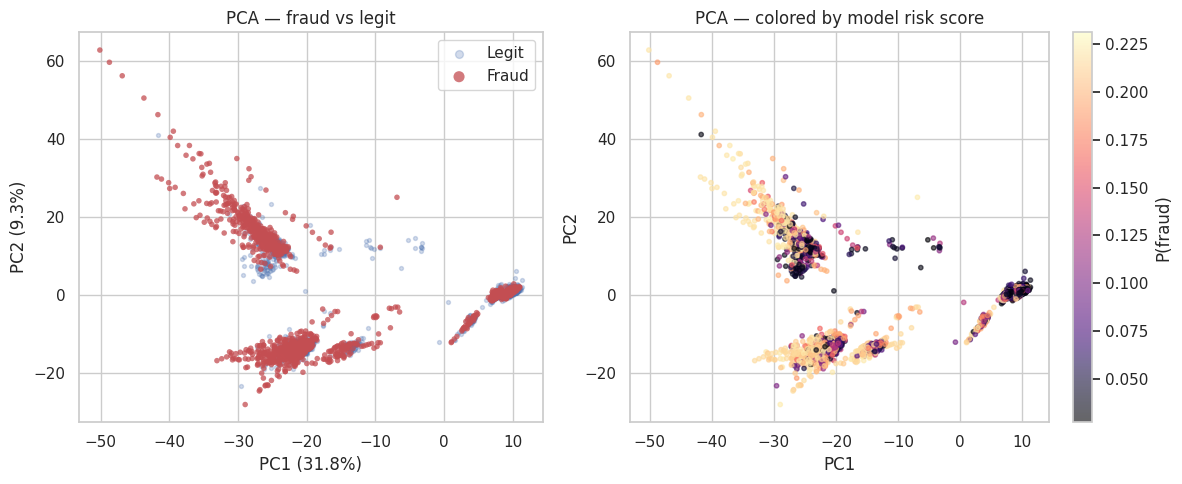

Saved pca_fraud_clusters.png


In [16]:
# ============================================================
# PCA + UMAP visualization (emphasize fraud cluster)
# ============================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed — run: !pip install umap-learn")
    print("PCA will still run.")

# Build a balanced-ish viz sample from TEST (or VAL)
rng = np.random.RandomState(42)
fraud_idx = np.where(y_test == 1)[0]
legit_idx = np.where(y_test == 0)[0]
n_fraud_viz = min(len(fraud_idx), 2000)
n_legit_viz = min(len(legit_idx), 6000)
f_take = rng.choice(fraud_idx, size=n_fraud_viz, replace=False)
l_take = rng.choice(legit_idx, size=n_legit_viz, replace=False)
viz_idx = np.concatenate([f_take, l_take])
rng.shuffle(viz_idx)

X_viz = X_test.iloc[viz_idx] if hasattr(X_test, "iloc") else X_test[viz_idx]
y_viz = y_test[viz_idx]
# optional risk score coloring from 5-seed avg if available
risk_viz = proba_test_5seed[viz_idx] if "proba_test_5seed" in dir() else None

scaler_v = StandardScaler()
X_scaled = scaler_v.fit_transform(X_viz)

# ---- PCA ----
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% (2 comps)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
leg = y_viz == 0
fr = y_viz == 1
ax.scatter(X_pca[leg, 0], X_pca[leg, 1], c="#4C72B0", s=8, alpha=0.25, label="Legit", rasterized=True)
ax.scatter(X_pca[fr, 0], X_pca[fr, 1], c="#C44E52", s=16, alpha=0.75, label="Fraud", edgecolors="none", rasterized=True)
ax.set_title("PCA — fraud vs legit")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=2)

ax = axes[1]
if risk_viz is not None:
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=risk_viz, cmap="magma", s=10, alpha=0.6, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.046, label="P(fraud)")
    ax.set_title("PCA — colored by model risk score")
else:
    ax.scatter(X_pca[leg, 0], X_pca[leg, 1], c="#4C72B0", s=8, alpha=0.25, rasterized=True)
    ax.scatter(X_pca[fr, 0], X_pca[fr, 1], c="#C44E52", s=16, alpha=0.75, rasterized=True)
    ax.set_title("PCA (no risk scores in memory)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/pca_fraud_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pca_fraud_clusters.png")


Fitting UMAP (may take 1–3 min)...


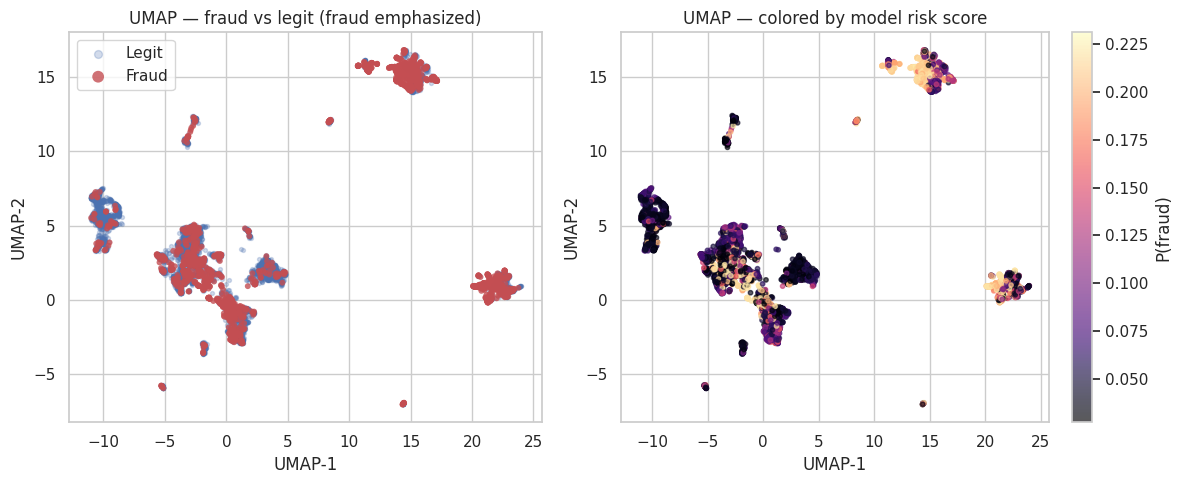

Saved umap_fraud_clusters.png


In [17]:
# ---- UMAP ----
if HAS_UMAP:
    print("Fitting UMAP (may take 1–3 min)...", flush=True)
    reducer = umap.UMAP(
        n_neighbors=30, min_dist=0.15, n_components=2,
        metric="euclidean", random_state=42, low_memory=True,
    )
    X_umap = reducer.fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.scatter(X_umap[leg, 0], X_umap[leg, 1], c="#4C72B0", s=8, alpha=0.25, label="Legit", rasterized=True)
    ax.scatter(X_umap[fr, 0], X_umap[fr, 1], c="#C44E52", s=18, alpha=0.8, label="Fraud", edgecolors="none", rasterized=True)
    ax.set_title("UMAP — fraud vs legit (fraud emphasized)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(markerscale=2)

    ax = axes[1]
    if risk_viz is not None:
        sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=risk_viz, cmap="magma", s=10, alpha=0.65, rasterized=True)
        plt.colorbar(sc, ax=ax, fraction=0.046, label="P(fraud)")
        ax.set_title("UMAP — colored by model risk score")
    else:
        ax.scatter(X_umap[leg, 0], X_umap[leg, 1], c="#4C72B0", s=8, alpha=0.25, rasterized=True)
        ax.scatter(X_umap[fr, 0], X_umap[fr, 1], c="#C44E52", s=18, alpha=0.8, rasterized=True)
        ax.set_title("UMAP")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/umap_fraud_clusters.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved umap_fraud_clusters.png")
else:
    print("Install umap-learn to generate UMAP plots:  !pip install umap-learn")


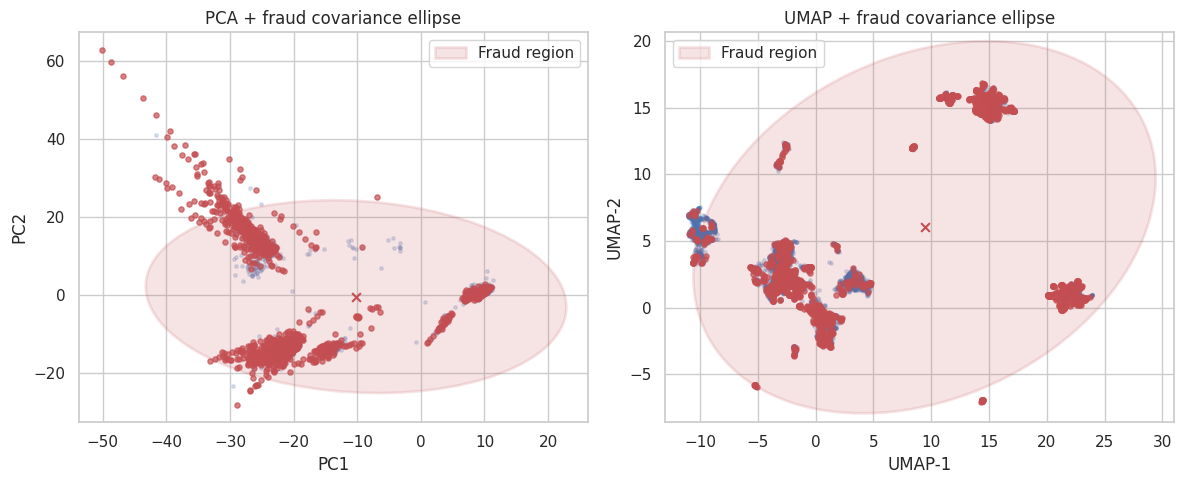

Saved fraud_ellipse_pca_umap.png
Use these figures to emphasize geometric separation / fraud concentration in the thesis.


In [18]:
# Optional: convex hull / circle annotation around fraud cloud in UMAP or PCA space
from matplotlib.patches import Ellipse
from sklearn.covariance import EmpiricalCovariance

def fraud_ellipse(ax, XY, y, label="Fraud region"):
    fr_pts = XY[y == 1]
    if len(fr_pts) < 10:
        return
    cov = EmpiricalCovariance().fit(fr_pts)
    vals, vecs = np.linalg.eigh(cov.covariance_)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    # 2-std ellipse
    width, height = 2 * 2 * np.sqrt(np.maximum(vals, 1e-9))
    center = fr_pts.mean(axis=0)
    ell = Ellipse(xy=center, width=width, height=height, angle=theta,
                  edgecolor="#C44E52", facecolor="#C44E52", alpha=0.15, lw=2, label=label)
    ax.add_patch(ell)
    ax.scatter([center[0]], [center[1]], c="#C44E52", s=40, marker="x", zorder=5)

fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(12 if HAS_UMAP else 6, 5))
if not HAS_UMAP:
    axes = [axes]

ax = axes[0]
ax.scatter(X_pca[leg, 0], X_pca[leg, 1], c="#4C72B0", s=6, alpha=0.2, rasterized=True)
ax.scatter(X_pca[fr, 0], X_pca[fr, 1], c="#C44E52", s=14, alpha=0.7, rasterized=True)
fraud_ellipse(ax, X_pca, y_viz)
ax.set_title("PCA + fraud covariance ellipse")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="best")

if HAS_UMAP:
    ax = axes[1]
    ax.scatter(X_umap[leg, 0], X_umap[leg, 1], c="#4C72B0", s=6, alpha=0.2, rasterized=True)
    ax.scatter(X_umap[fr, 0], X_umap[fr, 1], c="#C44E52", s=14, alpha=0.7, rasterized=True)
    fraud_ellipse(ax, X_umap, y_viz)
    ax.set_title("UMAP + fraud covariance ellipse")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(loc="best")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/fraud_ellipse_pca_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fraud_ellipse_pca_umap.png")
print("Use these figures to emphasize geometric separation / fraud concentration in the thesis.")


In [19]:
# Final JSON snippet for multi-seed
summary_seeds = {
    "seeds": SEEDS,
    "test_mean_std": tbl_test.to_dict(orient="records"),
    "val_mean_std": tbl_val.to_dict(orient="records"),
    "test_seed_avg_proba_metrics": ens5,
}
path = Path(CONFIG["output_dir"]) / "seed5_mean_std.json"
with open(path, "w") as f:
    json.dump(summary_seeds, f, indent=2)
print(json.dumps(summary_seeds, indent=2))
print("Saved", path)


{
  "seeds": [
    42,
    7,
    123,
    2024,
    99
  ],
  "test_mean_std": [
    {
      "Metric": "PR_AUC",
      "Mean": 0.5493,
      "Std": 0.0098,
      "Mean \u00b1 Std": "0.5493 \u00b1 0.0098"
    },
    {
      "Metric": "ROC_AUC",
      "Mean": 0.9351,
      "Std": 0.0015,
      "Mean \u00b1 Std": "0.9351 \u00b1 0.0015"
    },
    {
      "Metric": "Precision",
      "Mean": 0.0,
      "Std": 0.0,
      "Mean \u00b1 Std": "0.0000 \u00b1 0.0000"
    },
    {
      "Metric": "Recall",
      "Mean": 0.0,
      "Std": 0.0,
      "Mean \u00b1 Std": "0.0000 \u00b1 0.0000"
    },
    {
      "Metric": "F1",
      "Mean": 0.0,
      "Std": 0.0,
      "Mean \u00b1 Std": "0.0000 \u00b1 0.0000"
    },
    {
      "Metric": "MCC",
      "Mean": 0.0,
      "Std": 0.0,
      "Mean \u00b1 Std": "0.0000 \u00b1 0.0000"
    },
    {
      "Metric": "FC@1%",
      "Mean": 0.2034,
      "Std": 0.0059,
      "Mean \u00b1 Std": "0.2034 \u00b1 0.0059"
    },
    {
      "Metric": "FC@5%",
     